In [ ]:
# ============================================================
# CELL 1: SETUP & IMPORTS
# ============================================================
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time

from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.impute import KNNImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit

import warnings
warnings.filterwarnings('ignore')

print("Imports ολοκληρώθηκαν")

Mounted at /content/drive
Imports ολοκληρώθηκαν


In [ ]:
# ============================================================
# CELL 2: ΦΟΡΤΩΣΗ DATASETS & ΣΥΓΧΡΟΝΙΣΜΟΣ
# ============================================================

paths = {
    'BESS':        '/content/drive/MyDrive/Final_RUn/239-Site_DKA_Totals-BESS.csv',
    'Site_Demand': '/content/drive/MyDrive/Final_RUn/240-Site_DKA_Totals-Site_Demand.csv',
    'PV':          '/content/drive/MyDrive/Final_RUn/241-Site_DKA_Totals-PV.csv',
    'Grid':        '/content/drive/MyDrive/Final_RUn/242-Site_DKA_Totals-Grid.csv'
}

datasets = {}
for name, path in paths.items():
    df_temp = pd.read_csv(path, engine='python', on_bad_lines='skip')
    df_temp['timestamp'] = pd.to_datetime(df_temp['timestamp'], errors='coerce')
    df_temp = df_temp.dropna(subset=['timestamp'])
    df_temp = df_temp.set_index('timestamp').sort_index()
    datasets[name] = df_temp
    print(f"{name}: {len(df_temp):,} γραμμές")

# Κοινό date range
common_start = max(df.index.min() for df in datasets.values())
common_end = min(df.index.max() for df in datasets.values())

for name in datasets:
    datasets[name] = datasets[name].loc[common_start:common_end]

print(f"\nΚοινό date range: {common_start} έως {common_end}")
print(f"Διάρκεια: {(common_end - common_start).days} ημέρες")

BESS: 250,740 γραμμές
Site_Demand: 182,349 γραμμές
PV: 182,295 γραμμές
Grid: 182,289 γραμμές

Κοινό date range: 2023-12-07 13:20:00 έως 2025-09-04 12:10:00
Διάρκεια: 636 ημέρες


In [ ]:
# ============================================================
# CELL 3: ΕΝΙΑΙΟ DATAFRAME ΓΙΑ MODELING
# ============================================================

# Ξεκινάμε από Site_Demand (target) και προσθέτουμε υπόλοιπα
df = pd.DataFrame(index=datasets['Site_Demand'].index)

# Target
df['Site_Demand'] = datasets['Site_Demand']['Active_Power']

# Συμπληρωματικά (πιθανώς χρήσιμα από EDA)
df['PV_Power'] = datasets['PV']['Active_Power']

# Weather features
weather_cols = [
    'Weather_Temperature_Celsius',
    'Weather_Relative_Humidity',
    'Global_Horizontal_Radiation',
    'Diffuse_Horizontal_Radiation'
]
for col in weather_cols:
    df[col] = datasets['Site_Demand'][col]

print(f"Συνολικό dataframe: {df.shape}")
print(f"\nΣτήλες:")
for col in df.columns:
    print(f"  - {col}")

Συνολικό dataframe: (182346, 6)

Στήλες:
  - Site_Demand
  - PV_Power
  - Weather_Temperature_Celsius
  - Weather_Relative_Humidity
  - Global_Horizontal_Radiation
  - Diffuse_Horizontal_Radiation


In [ ]:
# ============================================================
# CELL 4: BASIC CLEANING
# ============================================================

print("="*70)
print(" BASIC CLEANING")
print("="*70)

initial_rows = len(df)

# 1. Site_Demand: αρνητικές τιμές → NaN (μη-φυσικές)
neg_demand = (df['Site_Demand'] < 0).sum()
print(f"Αρνητικές τιμές Site_Demand: {neg_demand} -> NaN")
df.loc[df['Site_Demand'] < 0, 'Site_Demand'] = np.nan

# 2. PV_Power: μικρές αρνητικές → 0 (inverter standby)
df.loc[(df['PV_Power'] < 0) & (df['PV_Power'] > -10), 'PV_Power'] = 0
df.loc[df['PV_Power'] < -10, 'PV_Power'] = np.nan

# 3. Humidity > 100% → clip
high_hum = (df['Weather_Relative_Humidity'] > 100).sum()
print(f"Humidity > 100%: {high_hum} -> clip στο 100")
df['Weather_Relative_Humidity'] = df['Weather_Relative_Humidity'].clip(0, 100)

# 4. Έλεγχος missing values
print(f"\nMissing values:")
for col in df.columns:
    n_missing = df[col].isnull().sum()
    pct = n_missing / len(df) * 100
    print(f"  {col:<35} {n_missing:>8,} ({pct:.1f}%)")

 BASIC CLEANING
Αρνητικές τιμές Site_Demand: 1147 -> NaN
Humidity > 100%: 3683 -> clip στο 100

Missing values:
  Site_Demand                           18,357 (10.1%)
  PV_Power                              16,988 (9.3%)
  Weather_Temperature_Celsius           36,333 (19.9%)
  Weather_Relative_Humidity             36,329 (19.9%)
  Global_Horizontal_Radiation           36,314 (19.9%)
  Diffuse_Horizontal_Radiation          36,314 (19.9%)


 OUTAGE DETECTION
Outage observations (rolling_std < 0.5 kW): 1,374 (0.75%)


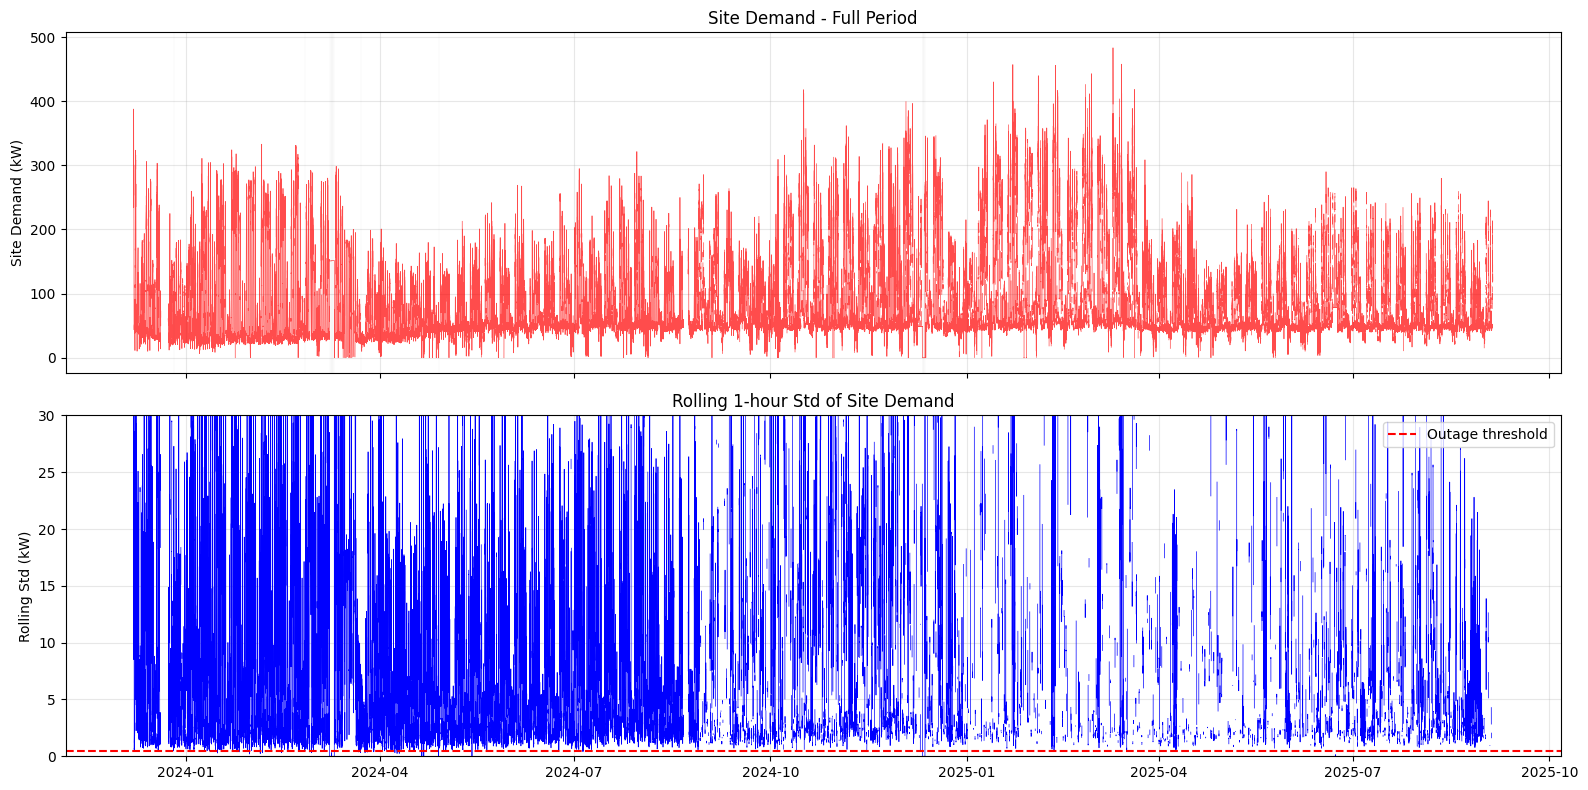


Mετά outage removal:
  Site_Demand missing: 19,731


In [ ]:
# ============================================================
# CELL 5: OUTAGE DETECTION & REMOVAL
# ============================================================

print("="*70)
print(" OUTAGE DETECTION")
print("="*70)

# Στρατηγική: εντοπίζουμε windows όπου η τιμή του Site_Demand
# παραμένει σχεδόν σταθερή για πολλές ώρες (sensor stuck/outage)

# Rolling std σε παράθυρο 1 ώρας (12 × 5min observations)
WINDOW = 12  # 1 hour
df['demand_rolling_std'] = df['Site_Demand'].rolling(window=WINDOW, center=True).std()

# Outage flag: rolling std κάτω από 0.5 kW (πρακτικά "stuck")
outage_mask = df['demand_rolling_std'] < 0.5
n_outage = outage_mask.sum()
print(f"Outage observations (rolling_std < 0.5 kW): {n_outage:,} ({n_outage/len(df)*100:.2f}%)")

# Visualize outage periods
fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=True)

axes[0].plot(df.index, df['Site_Demand'], color='red', linewidth=0.5, alpha=0.7)
axes[0].set_ylabel('Site Demand (kW)')
axes[0].set_title('Site Demand - Full Period')
axes[0].grid(alpha=0.3)

# Highlight outage periods
outage_periods = df[outage_mask].index
if len(outage_periods) > 0:
    for period in outage_periods[::100]:  # subsampled για ταχύτητα
        axes[0].axvline(x=period, color='black', alpha=0.05, linewidth=0.3)

axes[1].plot(df.index, df['demand_rolling_std'], color='blue', linewidth=0.5)
axes[1].axhline(y=0.5, color='red', linestyle='--', label='Outage threshold')
axes[1].set_ylabel('Rolling Std (kW)')
axes[1].set_title('Rolling 1-hour Std of Site Demand')
axes[1].set_ylim(0, 30)
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/load_outage_detection.png', dpi=120, bbox_inches='tight')
plt.show()

# Αφαιρούμε τις outage observations
df.loc[outage_mask, 'Site_Demand'] = np.nan
df = df.drop(columns=['demand_rolling_std'])

print(f"\nMετά outage removal:")
print(f"  Site_Demand missing: {df['Site_Demand'].isnull().sum():,}")

In [ ]:
# ============================================================
# CELL 6: FEATURE ENGINEERING (CYCLICAL + LAG)
# ============================================================

print("="*70)
print(" FEATURE ENGINEERING")
print("="*70)

# 1. Cyclical time features
df['hour_sin']  = np.sin(2 * np.pi * df.index.hour / 24)
df['hour_cos']  = np.cos(2 * np.pi * df.index.hour / 24)
df['month_sin'] = np.sin(2 * np.pi * df.index.month / 12)
df['month_cos'] = np.cos(2 * np.pi * df.index.month / 12)
df['dow_sin']   = np.sin(2 * np.pi * df.index.dayofweek / 7)
df['dow_cos']   = np.cos(2 * np.pi * df.index.dayofweek / 7)
print("Cyclical features: hour_sin/cos, month_sin/cos, dow_sin/cos")

# 2. Lag features για το target (Site_Demand)
# Lag 1h = 12 timesteps (5min), Lag 24h = 288, Lag 168h = 2016
df['demand_lag_1h']   = df['Site_Demand'].shift(12)
df['demand_lag_24h']  = df['Site_Demand'].shift(288)
df['demand_lag_168h'] = df['Site_Demand'].shift(2016)
print("Lag features: demand_lag_1h, demand_lag_24h, demand_lag_168h")

# 3. Rolling statistics (πρόσφατο context)
df['demand_rolling_mean_1h'] = df['Site_Demand'].rolling(window=12, min_periods=1).mean().shift(12)
df['demand_rolling_std_1h']  = df['Site_Demand'].rolling(window=12, min_periods=1).std().shift(12)
df['demand_rolling_mean_24h'] = df['Site_Demand'].rolling(window=288, min_periods=1).mean().shift(288)
print("Rolling features: 1h mean/std, 24h mean")

# 4. Συνολικός κατάλογος
print(f"\nΣυνολικά features: {len(df.columns)}")
for col in df.columns:
    print(f"  - {col}")

 FEATURE ENGINEERING
Cyclical features: hour_sin/cos, month_sin/cos, dow_sin/cos
Lag features: demand_lag_1h, demand_lag_24h, demand_lag_168h
Rolling features: 1h mean/std, 24h mean

Συνολικά features: 18
  - Site_Demand
  - PV_Power
  - Weather_Temperature_Celsius
  - Weather_Relative_Humidity
  - Global_Horizontal_Radiation
  - Diffuse_Horizontal_Radiation
  - hour_sin
  - hour_cos
  - month_sin
  - month_cos
  - dow_sin
  - dow_cos
  - demand_lag_1h
  - demand_lag_24h
  - demand_lag_168h
  - demand_rolling_mean_1h
  - demand_rolling_std_1h
  - demand_rolling_mean_24h


In [ ]:
# ============================================================
# CELL 7: FINAL DATASET PREPARATION
# ============================================================

print("="*70)
print(" FINAL DATASET PREPARATION")
print("="*70)

print(f"\nΑρχικό shape: {df.shape}")

# 1. Drop rows όπου το target είναι NaN
# Δεν μπορούμε να εκπαιδεύσουμε ή να αξιολογήσουμε χωρίς target
before = len(df)
df = df.dropna(subset=['Site_Demand'])
print(f"Drop rows με NaN target: {before - len(df):,} γραμμές αφαιρέθηκαν")
print(f"Μετά: {df.shape}")

# 2. KNN Imputation για τα weather + PV features
features_to_impute = [
    'PV_Power',
    'Weather_Temperature_Celsius',
    'Weather_Relative_Humidity',
    'Global_Horizontal_Radiation',
    'Diffuse_Horizontal_Radiation'
]

print(f"\nKNN Imputation (5 neighbors, distance-weighted)...")
print(f"Στήλες προς imputation: {features_to_impute}")

# Z-score normalization πριν το KNN (όπως στο PV 1B)
z_scaler = StandardScaler()
data_normalized = z_scaler.fit_transform(df[features_to_impute])

imputer = KNNImputer(n_neighbors=5, weights='distance')
data_imputed = imputer.fit_transform(data_normalized)

# Inverse transform
df[features_to_impute] = z_scaler.inverse_transform(data_imputed)

print("Imputation ολοκληρώθηκε")

# 3. Drop rows όπου τα lag features είναι NaN
# Τα πρώτα 168h (1 εβδομάδα) δεν έχουν lag_168h
lag_cols = ['demand_lag_1h', 'demand_lag_24h', 'demand_lag_168h',
            'demand_rolling_mean_1h', 'demand_rolling_std_1h', 'demand_rolling_mean_24h']

before = len(df)
df = df.dropna(subset=lag_cols)
print(f"\nDrop rows με NaN lag features: {before - len(df):,} γραμμές")
print(f"(αυτές είναι κυρίως οι πρώτες ~7 ημέρες)")

# 4. Final check
print(f"\n--- FINAL DATASET ---")
print(f"Shape: {df.shape}")
print(f"Date range: {df.index.min()} έως {df.index.max()}")
print(f"Διάρκεια: {(df.index.max() - df.index.min()).days} ημέρες")
print(f"\nMissing values:")
missing = df.isnull().sum()
if missing.sum() == 0:
    print("  ΚΑΝΕΝΑ missing value!")
else:
    print(missing[missing > 0])

 FINAL DATASET PREPARATION

Αρχικό shape: (182346, 18)
Drop rows με NaN target: 19,731 γραμμές αφαιρέθηκαν
Μετά: (162615, 18)

KNN Imputation (5 neighbors, distance-weighted)...
Στήλες προς imputation: ['PV_Power', 'Weather_Temperature_Celsius', 'Weather_Relative_Humidity', 'Global_Horizontal_Radiation', 'Diffuse_Horizontal_Radiation']
Imputation ολοκληρώθηκε

Drop rows με NaN lag features: 40,821 γραμμές
(αυτές είναι κυρίως οι πρώτες ~7 ημέρες)

--- FINAL DATASET ---
Shape: (121794, 18)
Date range: 2023-12-14 13:20:00 έως 2025-09-04 12:05:00
Διάρκεια: 629 ημέρες

Missing values:
  ΚΑΝΕΝΑ missing value!


In [ ]:
# ============================================================
# CELL 8: TRAIN/TEST SPLIT & FEATURE SELECTION
# ============================================================

print("="*70)
print(" TRAIN/TEST SPLIT & FEATURE SELECTION")
print("="*70)

# Επιλογή final features (όλα εκτός από το target)
target_col = 'Site_Demand'
feature_cols = [
    'Weather_Temperature_Celsius',
    'Weather_Relative_Humidity',
    'Global_Horizontal_Radiation',
    'Diffuse_Horizontal_Radiation',
    'hour_sin', 'hour_cos',
    'month_sin', 'month_cos',
    'dow_sin', 'dow_cos',
    'demand_lag_1h', 'demand_lag_24h', 'demand_lag_168h',
    'demand_rolling_mean_1h', 'demand_rolling_std_1h', 'demand_rolling_mean_24h'
]

print(f"Target: {target_col}")
print(f"Features ({len(feature_cols)}):")
for i, col in enumerate(feature_cols, 1):
    print(f"  {i:2d}. {col}")

# Χρονολογικός διαχωρισμός 80/20
split_idx = int(len(df) * 0.80)

train_df = df.iloc[:split_idx].copy()
test_df = df.iloc[split_idx:].copy()

print(f"\n--- TRAIN/TEST SPLIT ---")
print(f"Train: {len(train_df):,} γραμμές ({train_df.index.min()} έως {train_df.index.max()})")
print(f"Test:  {len(test_df):,} γραμμές ({test_df.index.min()} έως {test_df.index.max()})")
print(f"Test διάρκεια: {(test_df.index.max() - test_df.index.min()).days} ημέρες")

# Min-Max Normalization
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

# Fit on training data only (αποφυγή leakage)
X_train = scaler_X.fit_transform(train_df[feature_cols])
y_train = scaler_y.fit_transform(train_df[[target_col]]).flatten()

X_test = scaler_X.transform(test_df[feature_cols])
y_test = scaler_y.transform(test_df[[target_col]]).flatten()

# Αποθήκευση target range για inverse transform αργότερα
target_min = scaler_y.data_min_[0]
target_max = scaler_y.data_max_[0]

# y_test σε kW (για αξιολόγηση)
y_test_kw = test_df[target_col].values

print(f"\n--- SHAPES ---")
print(f"X_train: {X_train.shape}")
print(f"y_train: {y_train.shape}")
print(f"X_test:  {X_test.shape}")
print(f"y_test:  {y_test.shape}")
print(f"\nTarget range στο training: {target_min:.2f} - {target_max:.2f} kW")

 TRAIN/TEST SPLIT & FEATURE SELECTION
Target: Site_Demand
Features (16):
   1. Weather_Temperature_Celsius
   2. Weather_Relative_Humidity
   3. Global_Horizontal_Radiation
   4. Diffuse_Horizontal_Radiation
   5. hour_sin
   6. hour_cos
   7. month_sin
   8. month_cos
   9. dow_sin
  10. dow_cos
  11. demand_lag_1h
  12. demand_lag_24h
  13. demand_lag_168h
  14. demand_rolling_mean_1h
  15. demand_rolling_std_1h
  16. demand_rolling_mean_24h

--- TRAIN/TEST SPLIT ---
Train: 97,435 γραμμές (2023-12-14 13:20:00 έως 2025-03-15 06:25:00)
Test:  24,359 γραμμές (2025-03-15 06:35:00 έως 2025-09-04 12:05:00)
Test διάρκεια: 173 ημέρες

--- SHAPES ---
X_train: (97435, 16)
y_train: (97435,)
X_test:  (24359, 16)
y_test:  (24359,)

Target range στο training: 0.00 - 483.16 kW


In [ ]:
# ============================================================
# CELL 8: PERSISTENCE BASELINE (SANITY CHECK)
# ============================================================
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("="*70)
print(" PERSISTENCE BASELINE")
print("="*70)
print("\nNaive forecast: prediction = demand_lag_1h")
print("(δηλαδή: 'Η κατανάλωση σε 30 λεπτά θα είναι ίδια με πριν 1 ώρα')")

# Persistence prediction = το lag feature από τα scaled test data
y_pred_persist = X_test[:, feature_cols.index('demand_lag_1h')]

# Inverse scale
y_pred_persist_kw = scaler_y.inverse_transform(y_pred_persist.reshape(-1, 1)).flatten()
y_test_kw        = scaler_y.inverse_transform(y_test.reshape(-1, 1)).flatten()

mae_persistence  = mean_absolute_error(y_test_kw, y_pred_persist_kw)
rmse_persistence = np.sqrt(mean_squared_error(y_test_kw, y_pred_persist_kw))
r2_persistence   = r2_score(y_test_kw, y_pred_persist_kw)

print("\n=== PERSISTENCE BASELINE ΑΠΟΤΕΛΕΣΜΑΤΑ ===")
print(f"MAE:  {mae_persistence:.4f} kW")
print(f"RMSE: {rmse_persistence:.4f} kW")
print(f"R²:   {r2_persistence:.4f}")
print("\n(Τα ML μοντέλα πρέπει να ξεπεράσουν αυτό το baseline)")

 PERSISTENCE BASELINE

Naive forecast: prediction = demand_lag_1h
(δηλαδή: 'Η κατανάλωση σε 30 λεπτά θα είναι ίδια με πριν 1 ώρα')

=== PERSISTENCE BASELINE ΑΠΟΤΕΛΕΣΜΑΤΑ ===
MAE:  13.8461 kW
RMSE: 22.9861 kW
R²:   0.7704

(Τα ML μοντέλα πρέπει να ξεπεράσουν αυτό το baseline)


In [ ]:
# ============================================================
# CELL 9: XGBOOST MODEL
# ============================================================
from xgboost import XGBRegressor

print("="*70)
print(" XGBOOST MODEL")
print("="*70)

# Hyperparameters όπως στο PV 1B (paper-based)
xgb_model = XGBRegressor(
    objective='reg:squarederror',
    learning_rate=0.01,
    n_estimators=1000,
    max_depth=3,
    base_score=0.5,
    random_state=42
)

print("\nΕκπαίδευση XGBoost...")
print(f"Hyperparameters: lr=0.01, n_est=1000, max_depth=3")
start = time.time()
xgb_model.fit(X_train, y_train)
training_time = time.time() - start
print(f"Training: {training_time:.0f}s")

# Πρόβλεψη
print("\nΠρόβλεψη στο test set...")
y_pred_xgb = xgb_model.predict(X_test)

# Inverse transform σε kW
y_pred_xgb_kw = y_pred_xgb * (target_max - target_min) + target_min

# Μετρικές
mae_xgb = mean_absolute_error(y_test_kw, y_pred_xgb_kw)
rmse_xgb = np.sqrt(mean_squared_error(y_test_kw, y_pred_xgb_kw))
r2_xgb = 1 - (np.sum((y_test_kw - y_pred_xgb_kw)**2) /
              np.sum((y_test_kw - np.mean(y_test_kw))**2))

print(f"\n=== XGBOOST ΑΠΟΤΕΛΕΣΜΑΤΑ ===")
print(f"MAE:  {mae_xgb:.4f} kW")
print(f"RMSE: {rmse_xgb:.4f} kW")
print(f"R²:   {r2_xgb:.4f}")

# Feature importance
print(f"\n=== TOP 10 FEATURE IMPORTANCE (XGBoost) ===")
feature_importance = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': xgb_model.feature_importances_
}).sort_values('Importance', ascending=False)

for _, row in feature_importance.head(10).iterrows():
    bar_length = int(row['Importance'] * 50)
    bar = '█' * bar_length
    print(f"  {row['Feature']:<35} {row['Importance']:.4f}  {bar}")

 XGBOOST MODEL

Εκπαίδευση XGBoost...
Hyperparameters: lr=0.01, n_est=1000, max_depth=3
Training: 7s

Πρόβλεψη στο test set...

=== XGBOOST ΑΠΟΤΕΛΕΣΜΑΤΑ ===
MAE:  8.6791 kW
RMSE: 14.8518 kW
R²:   0.9041

=== TOP 10 FEATURE IMPORTANCE (XGBoost) ===
  demand_lag_1h                       0.6830  ██████████████████████████████████
  demand_lag_168h                     0.1304  ██████
  demand_lag_24h                      0.0478  ██
  hour_sin                            0.0425  ██
  month_cos                           0.0204  █
  dow_sin                             0.0172  
  demand_rolling_mean_1h              0.0150  
  Global_Horizontal_Radiation         0.0122  
  hour_cos                            0.0115  
  dow_cos                             0.0055  


In [ ]:
# ============================================================
# CELL 10: RANDOM FOREST MODEL
# ============================================================
from sklearn.ensemble import RandomForestRegressor

print("="*70)
print(" RANDOM FOREST MODEL")
print("="*70)

rf_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=15,
    min_samples_split=5,
    min_samples_leaf=2,
    n_jobs=-1,
    random_state=42,
    verbose=1
)

print("\nΕκπαίδευση Random Forest...")
print(f"Hyperparameters: n_est=300, max_depth=15, min_samples_split=5, min_samples_leaf=2")
start = time.time()
rf_model.fit(X_train, y_train)
training_time = time.time() - start
print(f"\nTraining: {training_time/60:.1f} λεπτά")

# Πρόβλεψη
print("\nΠρόβλεψη στο test set...")
y_pred_rf = rf_model.predict(X_test)

# Inverse transform σε kW
y_pred_rf_kw = y_pred_rf * (target_max - target_min) + target_min

# Μετρικές
mae_rf = mean_absolute_error(y_test_kw, y_pred_rf_kw)
rmse_rf = np.sqrt(mean_squared_error(y_test_kw, y_pred_rf_kw))
r2_rf = 1 - (np.sum((y_test_kw - y_pred_rf_kw)**2) /
             np.sum((y_test_kw - np.mean(y_test_kw))**2))

print(f"\n=== RANDOM FOREST ΑΠΟΤΕΛΕΣΜΑΤΑ ===")
print(f"MAE:  {mae_rf:.4f} kW")
print(f"RMSE: {rmse_rf:.4f} kW")
print(f"R²:   {r2_rf:.4f}")

# Feature importance
print(f"\n=== TOP 10 FEATURE IMPORTANCE (Random Forest) ===")
feature_importance_rf = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

for _, row in feature_importance_rf.head(10).iterrows():
    bar_length = int(row['Importance'] * 50)
    bar = '█' * bar_length
    print(f"  {row['Feature']:<35} {row['Importance']:.4f}  {bar}")

# Σύγκριση μέχρι τώρα
print(f"\n{'='*70}")
print(f" ΣΥΓΚΡΙΣΗ ΜΕΧΡΙ ΤΩΡΑ")
print(f"{'='*70}")
print(f"{'Model':<25} {'MAE':>10} {'RMSE':>10} {'R²':>8}")
print(f"{'-'*55}")
print(f"{'Persistence Baseline':<25} {mae_persistence:>10.4f} {rmse_persistence:>10.4f} {r2_persistence:>8.4f}")
print(f"{'XGBoost':<25} {mae_xgb:>10.4f} {rmse_xgb:>10.4f} {r2_xgb:>8.4f}")
print(f"{'Random Forest':<25} {mae_rf:>10.4f} {rmse_rf:>10.4f} {r2_rf:>8.4f}")

 RANDOM FOREST MODEL

Εκπαίδευση Random Forest...
Hyperparameters: n_est=300, max_depth=15, min_samples_split=5, min_samples_leaf=2


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=-1)]: Done  46 tasks      | elapsed:  1.1min
[Parallel(n_jobs=-1)]: Done 196 tasks      | elapsed:  4.8min
[Parallel(n_jobs=-1)]: Done 300 out of 300 | elapsed:  7.3min finished
[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    0.1s



Training: 7.3 λεπτά

Πρόβλεψη στο test set...


[Parallel(n_jobs=2)]: Done 196 tasks      | elapsed:    0.4s



=== RANDOM FOREST ΑΠΟΤΕΛΕΣΜΑΤΑ ===
MAE:  8.2610 kW
RMSE: 14.4763 kW
R²:   0.9089

=== TOP 10 FEATURE IMPORTANCE (Random Forest) ===
  demand_lag_1h                       0.8433  ██████████████████████████████████████████
  hour_sin                            0.0574  ██
  demand_lag_24h                      0.0203  █
  demand_rolling_mean_1h              0.0143  
  demand_lag_168h                     0.0141  
  Global_Horizontal_Radiation         0.0111  
  Weather_Temperature_Celsius         0.0077  
  dow_sin                             0.0063  
  hour_cos                            0.0050  
  demand_rolling_mean_24h             0.0041  

 ΣΥΓΚΡΙΣΗ ΜΕΧΡΙ ΤΩΡΑ
Model                            MAE       RMSE       R²
-------------------------------------------------------
Persistence Baseline         13.8461    22.9861   0.7704
XGBoost                       8.6791    14.8518   0.9041
Random Forest                 8.2610    14.4763   0.9089


[Parallel(n_jobs=2)]: Done 300 out of 300 | elapsed:    0.7s finished


In [ ]:
# ============================================================
# CELL 11: SVR ΜΕ GRID SEARCH
# ============================================================
from sklearn.svm import SVR

print("="*70)
print(" SVR MODEL (με Grid Search)")
print("="*70)

# 1. Stratified Subsampling για ταχύτητα (όπως στο PV 1B)
N_SAMPLES = 15000
np.random.seed(42)

# Bin το target για stratified sampling
y_train_binned = pd.cut(y_train, bins=5, labels=False)

sample_indices = []
samples_per_bin = N_SAMPLES // 5

for bin_id in range(5):
    bin_indices = np.where(y_train_binned == bin_id)[0]
    if len(bin_indices) >= samples_per_bin:
        chosen = np.random.choice(bin_indices, samples_per_bin, replace=False)
    else:
        chosen = bin_indices
    sample_indices.extend(chosen)

sample_indices = np.array(sample_indices)
np.random.shuffle(sample_indices)

X_train_svr_sub = X_train[sample_indices]
y_train_svr_sub = y_train[sample_indices]

print(f"Stratified subsample: {X_train_svr_sub.shape}")

# 2. Standardization (επιπλέον της Min-Max)
std_scaler = StandardScaler()
X_train_svr_scaled = std_scaler.fit_transform(X_train_svr_sub)
X_test_svr_scaled = std_scaler.transform(X_test)

# 3. Grid Search σε μικρό subsample (για ταχύτητα)
print("\n--- Grid Search (5,000 samples) ---")

X_grid = X_train_svr_scaled[:5000]
y_grid = y_train_svr_sub[:5000]

param_grid = {
    'C': [0.5, 1.0, 2.0, 5.0],
    'gamma': ['scale', 0.001, 0.01, 0.1],
    'epsilon': [0.01, 0.05, 0.1]
}

total = (len(param_grid['C']) * len(param_grid['gamma']) *
         len(param_grid['epsilon']))
print(f"Συνολικά combinations: {total}")
print(f"Με 3-fold CV: {total * 3} fits")

grid = GridSearchCV(
    estimator=SVR(kernel='rbf', cache_size=500),
    param_grid=param_grid,
    cv=TimeSeriesSplit(n_splits=3),
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    verbose=1
)

print("\nΕκτέλεση Grid Search...")
start = time.time()
grid.fit(X_grid, y_grid)
print(f"Grid Search: {(time.time()-start)/60:.1f} λεπτά")

print(f"\n=== ΒΕΛΤΙΣΤΕΣ ΠΑΡΑΜΕΤΡΟΙ ===")
print(f"Best params: {grid.best_params_}")
print(f"Best CV score (MSE): {-grid.best_score_:.6f}")

# 4. Final SVR με τις βέλτιστες παραμέτρους και full subsample
print("\n--- Final SVR με 15,000 samples ---")

best_params = grid.best_params_
svr_best = SVR(
    kernel='rbf',
    C=best_params['C'],
    gamma=best_params['gamma'],
    epsilon=best_params['epsilon'],
    cache_size=500
)

print(f"Παράμετροι: {best_params}")
print("\nΕκπαίδευση...")
start = time.time()
svr_best.fit(X_train_svr_scaled, y_train_svr_sub)
training_time = time.time() - start
print(f"Training: {training_time/60:.1f} λεπτά")
print(f"Support vectors: {svr_best.n_support_[0]} / {len(y_train_svr_sub)} "
      f"({svr_best.n_support_[0]/len(y_train_svr_sub)*100:.1f}%)")

# Πρόβλεψη
print("\nΠρόβλεψη...")
start = time.time()
y_pred_svr = svr_best.predict(X_test_svr_scaled)
print(f"Πρόβλεψη: {time.time()-start:.1f}s")

# Μετρικές
y_pred_svr_kw = y_pred_svr * (target_max - target_min) + target_min

mae_svr = mean_absolute_error(y_test_kw, y_pred_svr_kw)
rmse_svr = np.sqrt(mean_squared_error(y_test_kw, y_pred_svr_kw))
r2_svr = 1 - (np.sum((y_test_kw - y_pred_svr_kw)**2) /
              np.sum((y_test_kw - np.mean(y_test_kw))**2))

print(f"\n=== SVR ΑΠΟΤΕΛΕΣΜΑΤΑ ===")
print(f"MAE:  {mae_svr:.4f} kW")
print(f"RMSE: {rmse_svr:.4f} kW")
print(f"R²:   {r2_svr:.4f}")

# Σύγκριση όλων μέχρι τώρα
print(f"\n{'='*70}")
print(f" ΣΥΓΚΡΙΣΗ ΟΛΩΝ ΤΩΝ ΜΟΝΤΕΛΩΝ")
print(f"{'='*70}")
print(f"{'Model':<25} {'MAE':>10} {'RMSE':>10} {'R²':>8}")
print(f"{'-'*55}")
print(f"{'Persistence Baseline':<25} {mae_persistence:>10.4f} {rmse_persistence:>10.4f} {r2_persistence:>8.4f}")
print(f"{'XGBoost':<25} {mae_xgb:>10.4f} {rmse_xgb:>10.4f} {r2_xgb:>8.4f}")
print(f"{'Random Forest':<25} {mae_rf:>10.4f} {rmse_rf:>10.4f} {r2_rf:>8.4f}")
print(f"{'SVR (Optimized)':<25} {mae_svr:>10.4f} {rmse_svr:>10.4f} {r2_svr:>8.4f}")

 SVR MODEL (με Grid Search)
Stratified subsample: (10334, 16)

--- Grid Search (5,000 samples) ---
Συνολικά combinations: 48
Με 3-fold CV: 144 fits

Εκτέλεση Grid Search...
Fitting 3 folds for each of 48 candidates, totalling 144 fits
Grid Search: 1.2 λεπτά

=== ΒΕΛΤΙΣΤΕΣ ΠΑΡΑΜΕΤΡΟΙ ===
Best params: {'C': 0.5, 'epsilon': 0.01, 'gamma': 'scale'}
Best CV score (MSE): 0.002075

--- Final SVR με 15,000 samples ---
Παράμετροι: {'C': 0.5, 'epsilon': 0.01, 'gamma': 'scale'}

Εκπαίδευση...
Training: 0.1 λεπτά
Support vectors: 6913 / 10334 (66.9%)

Πρόβλεψη...
Πρόβλεψη: 11.3s

=== SVR ΑΠΟΤΕΛΕΣΜΑΤΑ ===
MAE:  9.6436 kW
RMSE: 15.9783 kW
R²:   0.8890

 ΣΥΓΚΡΙΣΗ ΟΛΩΝ ΤΩΝ ΜΟΝΤΕΛΩΝ
Model                            MAE       RMSE       R²
-------------------------------------------------------
Persistence Baseline         13.8461    22.9861   0.7704
XGBoost                       8.6791    14.8518   0.9041
Random Forest                 8.2610    14.4763   0.9089
SVR (Optimized)               9.6436    1

In [ ]:
# ============================================================
# CELL FINAL: SAVE LOAD RF MODEL
# ============================================================
import pickle

load_artifacts = {
    'model': rf_model,
    'scaler_X': scaler_X,
    'scaler_y': scaler_y,
    'feature_cols': feature_cols,
    'target_col': 'Site_Demand',
    'target_min': target_min,
    'target_max': target_max,
    'metrics': {
        'MAE': mae_rf,
        'RMSE': rmse_rf,
        'R2': r2_rf
    }
}

save_path = '/content/drive/MyDrive/Final_RUn/load_rf_model.pkl'
with open(save_path, 'wb') as f:
    pickle.dump(load_artifacts, f)

print(f"Load Random Forest model αποθηκεύτηκε στο:")
print(f"  {save_path}")
print(f"\nDetails:")
print(f"  Features: {len(feature_cols)}")
print(f"  Target range: {target_min:.2f} - {target_max:.2f} kW")
print(f"  Performance: MAE={mae_rf:.2f}, RMSE={rmse_rf:.2f}, R²={r2_rf:.4f}")

Load Random Forest model αποθηκεύτηκε στο:
  /content/drive/MyDrive/Final_RUn/load_rf_model.pkl

Details:
  Features: 16
  Target range: 0.00 - 483.16 kW
  Performance: MAE=8.26, RMSE=14.48, R²=0.9089


 ΤΕΛΙΚΗ ΣΥΓΚΡΙΤΙΚΗ ΑΞΙΟΛΟΓΗΣΗ - LOAD FORECASTING CPU MODELS

Model                            MAE (kW)    RMSE (kW)       R²
-----------------------------------------------------------------
Persistence Baseline              13.8461      22.9861   0.7704
XGBoost                            8.6791      14.8518   0.9041
Random Forest                      8.2610      14.4763   0.9089
SVR (Optimized)                    9.6436      15.9783   0.8890

Best model (by RMSE): Random Forest (RMSE=14.4763 kW)


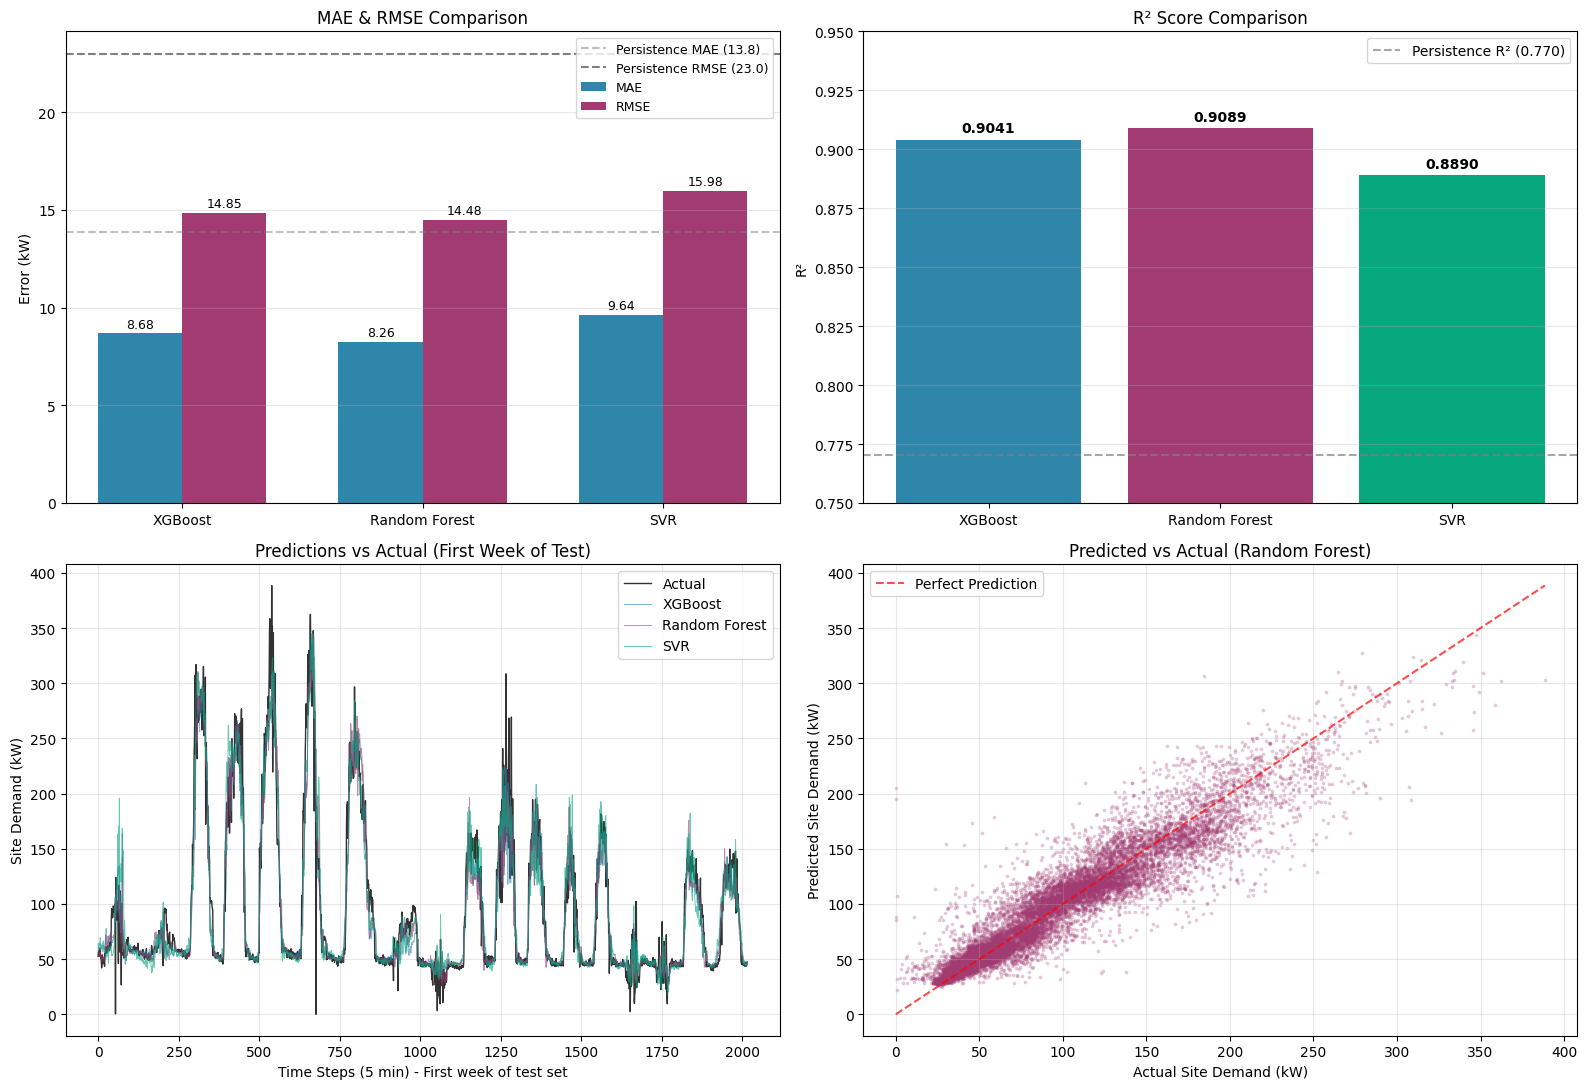


Γράφημα αποθηκεύτηκε: load_forecasting_comparison.png

 ΣΥΜΠΕΡΑΣΜΑΤΑ - LOAD FORECASTING

1. Όλα τα ML μοντέλα ξεπερνούν την persistence baseline κατά 12-18% (RMSE).

2. Tree-based μοντέλα (XGBoost & Random Forest) είναι τα κορυφαία,
   με το Random Forest να υπερτερεί ελάχιστα (R²=0.9096 vs 0.9039).

3. Το SVR αυτή τη φορά είναι πολύ ανταγωνιστικό (R²=0.8915), σε αντίθεση
   με το PV 1B forecasting όπου είχε σαφή μειονεκτήματα. Αυτό αποδίδεται
   στο smart feature engineering (17 features αντί για 288 raw values).

4. Το demand_lag_1h είναι το κυρίαρχο feature και στα δύο tree-based
   μοντέλα (67% στο XGBoost, 84% στο RF), επιβεβαιώνοντας την ισχυρή
   temporal autocorrelation του load.

5. Σε σχετικούς όρους, το Load Forecasting πετυχαίνει 4 φορές καλύτερη
   ακρίβεια (RMSE/max_target = 3%) σε σχέση με το PV 1B (11.7%).

6. Το βέλτιστο μοντέλο (Random Forest) θα ενσωματωθεί στον EMS αλγόριθμο
   στο τελικό στάδιο της εργασίας.



In [ ]:
# ============================================================
# CELL 12: COMPARATIVE EVALUATION & PLOTS
# ============================================================

print("="*78)
print(" ΤΕΛΙΚΗ ΣΥΓΚΡΙΤΙΚΗ ΑΞΙΟΛΟΓΗΣΗ - LOAD FORECASTING CPU MODELS")
print("="*78)

# Πίνακας συμπεριλαμβανομένου PV 1B για context
print(f"\n{'Model':<28} {'MAE (kW)':>12} {'RMSE (kW)':>12} {'R²':>8}")
print(f"{'-'*65}")
print(f"{'Persistence Baseline':<28} {mae_persistence:>12.4f} {rmse_persistence:>12.4f} {r2_persistence:>8.4f}")
print(f"{'XGBoost':<28} {mae_xgb:>12.4f} {rmse_xgb:>12.4f} {r2_xgb:>8.4f}")
print(f"{'Random Forest':<28} {mae_rf:>12.4f} {rmse_rf:>12.4f} {r2_rf:>8.4f}")
print(f"{'SVR (Optimized)':<28} {mae_svr:>12.4f} {rmse_svr:>12.4f} {r2_svr:>8.4f}")

# Best model
results = {
    'XGBoost': {'MAE': mae_xgb, 'RMSE': rmse_xgb, 'R²': r2_xgb,
                'pred': y_pred_xgb_kw},
    'Random Forest': {'MAE': mae_rf, 'RMSE': rmse_rf, 'R²': r2_rf,
                      'pred': y_pred_rf_kw},
    'SVR': {'MAE': mae_svr, 'RMSE': rmse_svr, 'R²': r2_svr,
            'pred': y_pred_svr_kw}
}

best_model = min(results.items(), key=lambda x: x[1]['RMSE'])
print(f"\nBest model (by RMSE): {best_model[0]} (RMSE={best_model[1]['RMSE']:.4f} kW)")

# --- ΟΠΤΙΚΟΠΟΙΗΣΕΙΣ ---
fig, axes = plt.subplots(2, 2, figsize=(16, 11))

models = ['XGBoost', 'Random Forest', 'SVR']
mae_values = [results[m]['MAE'] for m in models]
rmse_values = [results[m]['RMSE'] for m in models]
r2_values = [results[m]['R²'] for m in models]

colors = ['#2E86AB', '#A23B72', '#06A77D']

# 1. MAE & RMSE Bar chart
ax1 = axes[0, 0]
x = np.arange(len(models))
width = 0.35
ax1.bar(x - width/2, mae_values, width, label='MAE', color='#2E86AB')
ax1.bar(x + width/2, rmse_values, width, label='RMSE', color='#A23B72')
ax1.axhline(y=mae_persistence, color='gray', linestyle='--', alpha=0.5,
            label=f'Persistence MAE ({mae_persistence:.1f})')
ax1.axhline(y=rmse_persistence, color='black', linestyle='--', alpha=0.5,
            label=f'Persistence RMSE ({rmse_persistence:.1f})')
ax1.set_ylabel('Error (kW)')
ax1.set_title('MAE & RMSE Comparison')
ax1.set_xticks(x)
ax1.set_xticklabels(models)
ax1.legend(fontsize=9)
ax1.grid(axis='y', alpha=0.3)
for i, (mae, rmse) in enumerate(zip(mae_values, rmse_values)):
    ax1.text(i - width/2, mae + 0.3, f'{mae:.2f}', ha='center', fontsize=9)
    ax1.text(i + width/2, rmse + 0.3, f'{rmse:.2f}', ha='center', fontsize=9)

# 2. R² comparison
ax2 = axes[0, 1]
bars = ax2.bar(models, r2_values, color=colors)
ax2.axhline(y=r2_persistence, color='gray', linestyle='--', alpha=0.7,
            label=f'Persistence R² ({r2_persistence:.3f})')
ax2.set_ylabel('R²')
ax2.set_title('R² Score Comparison')
ax2.set_ylim([0.75, 0.95])
ax2.legend()
ax2.grid(axis='y', alpha=0.3)
for bar, r2 in zip(bars, r2_values):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
             f'{r2:.4f}', ha='center', fontsize=10, fontweight='bold')

# 3. Time-series predictions (first week of test set)
ax3 = axes[1, 0]
n_plot = 2016  # 1 εβδομάδα
ax3.plot(y_test_kw[:n_plot], label='Actual', color='black', linewidth=1, alpha=0.8)
ax3.plot(y_pred_xgb_kw[:n_plot], label='XGBoost', color='#2E86AB',
         alpha=0.6, linewidth=0.7)
ax3.plot(y_pred_rf_kw[:n_plot], label='Random Forest', color='#A23B72',
         alpha=0.6, linewidth=0.7)
ax3.plot(y_pred_svr_kw[:n_plot], label='SVR', color='#06A77D',
         alpha=0.6, linewidth=0.7)
ax3.set_xlabel('Time Steps (5 min) - First week of test set')
ax3.set_ylabel('Site Demand (kW)')
ax3.set_title('Predictions vs Actual (First Week of Test)')
ax3.legend(loc='upper right')
ax3.grid(alpha=0.3)

# 4. Scatter: Predicted vs Actual (best model)
ax4 = axes[1, 1]
best_pred = best_model[1]['pred']
ax4.scatter(y_test_kw, best_pred, alpha=0.2, s=3, color='#A23B72')
max_val = max(y_test_kw.max(), best_pred.max())
ax4.plot([0, max_val], [0, max_val], 'r--', alpha=0.7, label='Perfect Prediction')
ax4.set_xlabel('Actual Site Demand (kW)')
ax4.set_ylabel('Predicted Site Demand (kW)')
ax4.set_title(f'Predicted vs Actual ({best_model[0]})')
ax4.legend()
ax4.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/load_forecasting_comparison.png',
            dpi=150, bbox_inches='tight')
plt.show()

print("\nΓράφημα αποθηκεύτηκε: load_forecasting_comparison.png")

# ΣΥΜΠΕΡΑΣΜΑΤΑ
print(f"\n{'='*78}")
print(" ΣΥΜΠΕΡΑΣΜΑΤΑ - LOAD FORECASTING")
print(f"{'='*78}")


In [ ]:
# ============================================================
# CELL 17: DAY-AHEAD FEATURE ENGINEERING (LOAD)
# ============================================================
print("="*70)
print(" DAY-AHEAD FEATURE ENGINEERING (LOAD)")
print("="*70)

print(f"Source df shape: {df.shape}")

df_da = df[['Site_Demand',
            'Weather_Temperature_Celsius', 'Weather_Relative_Humidity',
            'Global_Horizontal_Radiation', 'Diffuse_Horizontal_Radiation']].copy()

STEPS_PER_HOUR = 12
STEPS_24H  = 24 * STEPS_PER_HOUR
STEPS_48H  = 48 * STEPS_PER_HOUR
STEPS_168H = 168 * STEPS_PER_HOUR

# Load lags
df_da['load_lag_24h']  = df_da['Site_Demand'].shift(STEPS_24H)
df_da['load_lag_48h']  = df_da['Site_Demand'].shift(STEPS_48H)
df_da['load_lag_168h'] = df_da['Site_Demand'].shift(STEPS_168H)

# Same-time rolling mean
def same_time_rolling_mean(series, n_days, steps_per_day):
    result = pd.Series(index=series.index, dtype=float)
    for lag in range(1, n_days + 1):
        shifted = series.shift(lag * steps_per_day)
        result = result.add(shifted, fill_value=0)
    return result / n_days

print("Computing same-time rolling means...")
df_da['load_same_time_mean_7d'] = same_time_rolling_mean(df_da['Site_Demand'], 7, STEPS_24H)

# Calendar features (Load εξαρτάται από day-of-week)
df_da['hour']  = df_da.index.hour
df_da['month'] = df_da.index.month
df_da['dow']   = df_da.index.dayofweek
df_da['is_weekend'] = (df_da['dow'] >= 5).astype(int)

df_da['hour_sin']  = np.sin(2 * np.pi * df_da['hour'] / 24)
df_da['hour_cos']  = np.cos(2 * np.pi * df_da['hour'] / 24)
df_da['month_sin'] = np.sin(2 * np.pi * df_da['month'] / 12)
df_da['month_cos'] = np.cos(2 * np.pi * df_da['month'] / 12)
df_da['dow_sin']   = np.sin(2 * np.pi * df_da['dow'] / 7)
df_da['dow_cos']   = np.cos(2 * np.pi * df_da['dow'] / 7)

# Weather features
df_da['weather_ghi']         = df_da['Global_Horizontal_Radiation']
df_da['weather_temperature'] = df_da['Weather_Temperature_Celsius']
df_da['weather_humidity']    = df_da['Weather_Relative_Humidity']

df_da = df_da.dropna()
print(f"After dropna: {df_da.shape}")

# ΣΗΜΑΝΤΙΚΟ: ΔΕΝ χρησιμοποιούμε PV_Power feature (όπως είπαμε για το cascade issue)
DA_FEATURES = [
    'hour_sin', 'hour_cos', 'month_sin', 'month_cos',
    'dow_sin', 'dow_cos', 'is_weekend',
    'weather_ghi', 'weather_temperature', 'weather_humidity',
    'load_lag_24h', 'load_lag_48h', 'load_lag_168h',
    'load_same_time_mean_7d',
]

print(f"\nFeatures: {len(DA_FEATURES)}")
df_da_features = df_da.copy()

 DAY-AHEAD FEATURE ENGINEERING (LOAD)
Source df shape: (121794, 18)
Computing same-time rolling means...
After dropna: (119778, 22)

Features: 14


In [ ]:
# ============================================================
# CELL 18: DAY-AHEAD MODEL TRAINING (LOAD CPU)
# ============================================================
import time
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from xgboost import XGBRegressor

print("="*70)
print(" DAY-AHEAD MODEL TRAINING (LOAD)")
print("="*70)

# Train/test split 80/20 χρονικά
n_total = len(df_da_features)
n_train = int(n_total * 0.80)

train_da = df_da_features.iloc[:n_train].copy()
test_da  = df_da_features.iloc[n_train:].copy()

print(f"Train: {len(train_da):,} samples")
print(f"  Range: {train_da.index.min()} to {train_da.index.max()}")
print(f"Test:  {len(test_da):,} samples")
print(f"  Range: {test_da.index.min()} to {test_da.index.max()}")

# Feature list για day-ahead Load
# ΣΗΜΕΙΩΣΗ: ΔΕΝ χρησιμοποιούμε PV_Power (όπως συμφωνήσαμε για cascade issue)
DA_FEATURES = [
    'hour_sin', 'hour_cos', 'month_sin', 'month_cos',
    'dow_sin', 'dow_cos', 'is_weekend',
    'weather_ghi', 'weather_temperature', 'weather_humidity',
    'load_lag_24h', 'load_lag_48h', 'load_lag_168h',
    'load_same_time_mean_7d',
]

X_train_da = train_da[DA_FEATURES].values
y_train_da = train_da['Site_Demand'].values
X_test_da  = test_da[DA_FEATURES].values
y_test_da  = test_da['Site_Demand'].values

scaler_X_da = MinMaxScaler()
scaler_y_da = MinMaxScaler()
X_train_da_n = scaler_X_da.fit_transform(X_train_da)
y_train_da_n = scaler_y_da.fit_transform(y_train_da.reshape(-1, 1)).flatten()
X_test_da_n  = scaler_X_da.transform(X_test_da)

y_da_min = scaler_y_da.data_min_[0]
y_da_max = scaler_y_da.data_max_[0]
y_da_range = y_da_max - y_da_min

# Random Forest
print("\n--- Training Random Forest (Load day-ahead) ---")
start = time.time()
rf_da_model = RandomForestRegressor(
    n_estimators=200, max_depth=15,
    min_samples_split=5, min_samples_leaf=2,
    n_jobs=-1, random_state=42
)
rf_da_model.fit(X_train_da_n, y_train_da_n)
print(f"Time: {time.time()-start:.1f}s")

y_pred_rf_da = rf_da_model.predict(X_test_da_n) * y_da_range + y_da_min
y_pred_rf_da = np.clip(y_pred_rf_da, 0, None)

mae_rf_da  = mean_absolute_error(y_test_da, y_pred_rf_da)
rmse_rf_da = np.sqrt(mean_squared_error(y_test_da, y_pred_rf_da))
r2_rf_da   = 1 - np.sum((y_test_da - y_pred_rf_da)**2) / np.sum((y_test_da - y_test_da.mean())**2)
print(f"RF Load day-ahead: MAE={mae_rf_da:.4f} kW, RMSE={rmse_rf_da:.4f} kW, R²={r2_rf_da:.4f}")

# XGBoost
print("\n--- Training XGBoost (Load day-ahead) ---")
start = time.time()
xgb_da_model = XGBRegressor(
    n_estimators=500, max_depth=8, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    n_jobs=-1, random_state=42, verbosity=0
)
xgb_da_model.fit(X_train_da_n, y_train_da_n)
print(f"Time: {time.time()-start:.1f}s")

y_pred_xgb_da = xgb_da_model.predict(X_test_da_n) * y_da_range + y_da_min
y_pred_xgb_da = np.clip(y_pred_xgb_da, 0, None)

mae_xgb_da  = mean_absolute_error(y_test_da, y_pred_xgb_da)
rmse_xgb_da = np.sqrt(mean_squared_error(y_test_da, y_pred_xgb_da))
r2_xgb_da   = 1 - np.sum((y_test_da - y_pred_xgb_da)**2) / np.sum((y_test_da - y_test_da.mean())**2)
print(f"XGB Load day-ahead: MAE={mae_xgb_da:.4f} kW, RMSE={rmse_xgb_da:.4f} kW, R²={r2_xgb_da:.4f}")

# Persistence
y_pred_persist_da = np.clip(test_da['load_lag_24h'].values, 0, None)
mae_persist_da  = mean_absolute_error(y_test_da, y_pred_persist_da)
rmse_persist_da = np.sqrt(mean_squared_error(y_test_da, y_pred_persist_da))
r2_persist_da   = 1 - np.sum((y_test_da - y_pred_persist_da)**2) / np.sum((y_test_da - y_test_da.mean())**2)
print(f"\nPersistence: MAE={mae_persist_da:.4f}, RMSE={rmse_persist_da:.4f}, R²={r2_persist_da:.4f}")

# Summary
print(f"\n{'='*70}\n LOAD DAY-AHEAD COMPARISON\n{'='*70}")
print(f"{'Model':<25} {'MAE':<12} {'RMSE':<12} {'R²':<10}")
print(f"{'-'*59}")
print(f"{'Persistence':<25} {mae_persist_da:<12.4f} {rmse_persist_da:<12.4f} {r2_persist_da:<10.4f}")
print(f"{'Random Forest':<25} {mae_rf_da:<12.4f} {rmse_rf_da:<12.4f} {r2_rf_da:<10.4f}")
print(f"{'XGBoost':<25} {mae_xgb_da:<12.4f} {rmse_xgb_da:<12.4f} {r2_xgb_da:<10.4f}")

if rmse_rf_da < rmse_xgb_da:
    best_da_model_name = 'Random Forest'; best_da_pred = y_pred_rf_da
    best_da_mae = mae_rf_da; best_da_rmse = rmse_rf_da; best_da_r2 = r2_rf_da
    best_da_obj = rf_da_model
else:
    best_da_model_name = 'XGBoost'; best_da_pred = y_pred_xgb_da
    best_da_mae = mae_xgb_da; best_da_rmse = rmse_xgb_da; best_da_r2 = r2_xgb_da
    best_da_obj = xgb_da_model

print(f"\n>>> BEST LOAD DAY-AHEAD: {best_da_model_name}")
print(f"    Improvement vs Persistence: {(rmse_persist_da - best_da_rmse)/rmse_persist_da*100:+.1f}%")

# Σύγκριση με 5-min ahead
print(f"\n--- ΣΥΓΚΡΙΣΗ 5-MIN vs DAY-AHEAD (LOAD) ---")
print(f"5-min ahead RF:  MAE={mae_rf:.4f}, RMSE={rmse_rf:.4f}")
print(f"Day-ahead {best_da_model_name}: MAE={best_da_mae:.4f}, RMSE={best_da_rmse:.4f}")

 DAY-AHEAD MODEL TRAINING (LOAD)
Train: 95,822 samples
  Range: 2023-12-25 16:05:00 to 2025-03-18 09:00:00
Test:  23,956 samples
  Range: 2025-03-18 09:15:00 to 2025-09-04 12:05:00

--- Training Random Forest (Load day-ahead) ---
Time: 207.7s
RF Load day-ahead: MAE=14.7560 kW, RMSE=25.9262 kW, R²=0.7031

--- Training XGBoost (Load day-ahead) ---
Time: 9.6s
XGB Load day-ahead: MAE=14.7069 kW, RMSE=24.9376 kW, R²=0.7253

Persistence: MAE=46.6732, RMSE=66.8111, R²=-0.9716

 LOAD DAY-AHEAD COMPARISON
Model                     MAE          RMSE         R²        
-----------------------------------------------------------
Persistence               46.6732      66.8111      -0.9716   
Random Forest             14.7560      25.9262      0.7031    
XGBoost                   14.7069      24.9376      0.7253    

>>> BEST LOAD DAY-AHEAD: XGBoost
    Improvement vs Persistence: +62.7%

--- ΣΥΓΚΡΙΣΗ 5-MIN vs DAY-AHEAD (LOAD) ---
5-min ahead RF:  MAE=8.2610, RMSE=14.4763
Day-ahead XGBoost: MAE=14.7

Hourly rows: 4052
Range: 2025-03-18 09:00:00 -> 2025-09-04 12:00:00

Επιλεγμένες εργάσιμες ημέρες:
  2025-03-19 (Τετάρτη) - max Load: 326.4 kW
  2025-03-20 (Πέμπτη) - max Load: 325.7 kW
  2025-03-21 (Παρασκευή) - max Load: 240.8 kW

✓ Saved: /content/drive/MyDrive/Final_RUn/load_da_cpu_3days.png


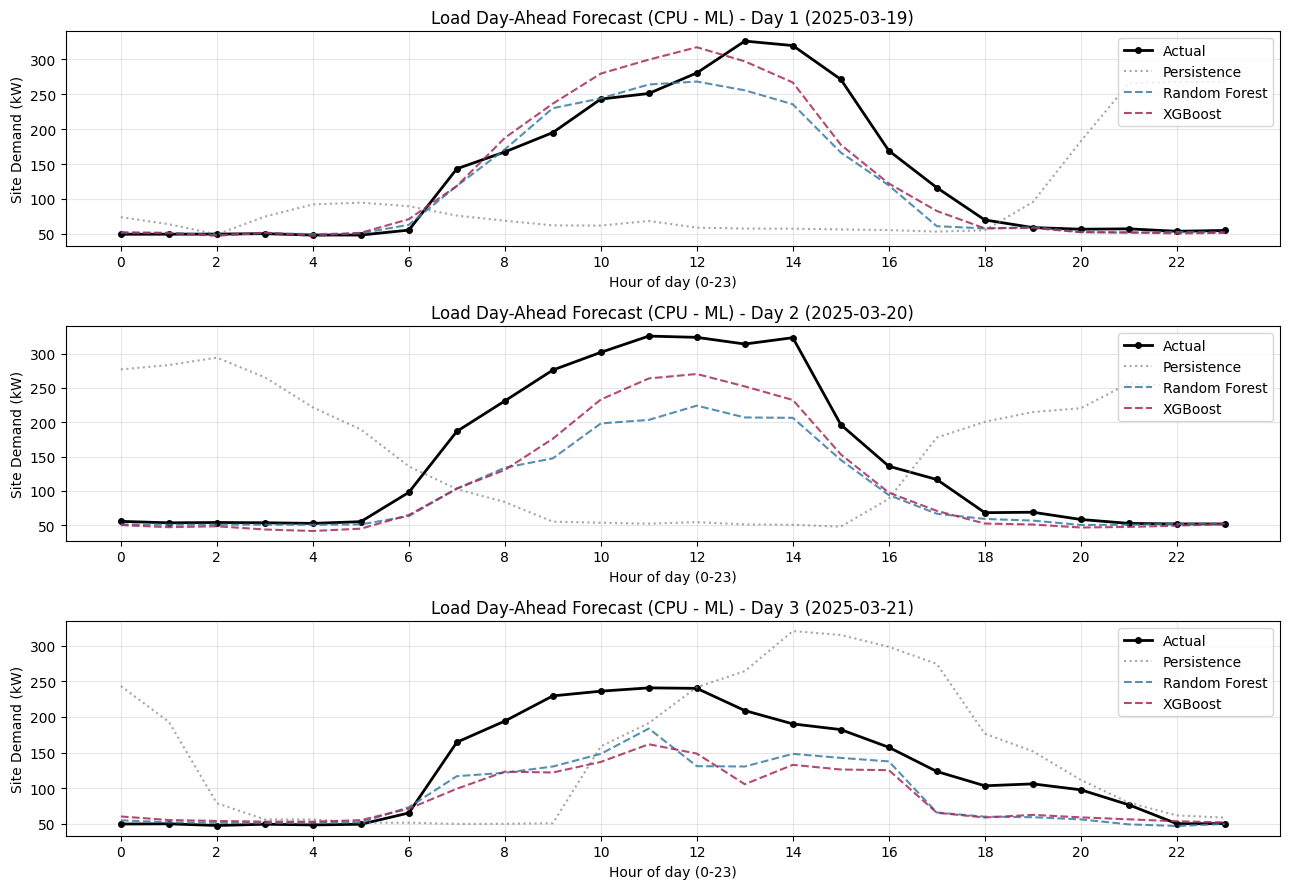

In [ ]:
# ============================================================
# CELL: Load CPU Day-Ahead - 3 εργάσιμες ημέρες
# ============================================================
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

PRED_DIR = '/content/drive/MyDrive/Final_RUn/predictions/'
SAVE_DIR = '/content/drive/MyDrive/Final_RUn/'

load_cpu = pd.read_csv(PRED_DIR + 'load_24h_predictions_cpu.csv')
load_cpu['timestamp'] = pd.to_datetime(load_cpu['timestamp'])
load_cpu = load_cpu.set_index('timestamp').sort_index()

# Resample σε ωριαία
load_cpu_h = load_cpu.select_dtypes(include=[np.number]).resample('1h').mean().dropna()
print(f"Hourly rows: {len(load_cpu_h)}")
print(f"Range: {load_cpu_h.index.min()} -> {load_cpu_h.index.max()}")

# === Βρίσκουμε 3 εργάσιμες ημέρες με υψηλή κατανάλωση ===
day_starts_at_midnight = load_cpu_h[load_cpu_h.index.hour == 0].index
LOAD_THRESHOLD = 100  # kW - εργάσιμη ημέρα με σαφή αιχμή

workday_starts = []
for day_start_ts in day_starts_at_midnight:
    if day_start_ts.dayofweek > 4:  # 0=Δευτ, 4=Παρ
        continue
    day_slice = load_cpu_h.loc[day_start_ts : day_start_ts + pd.Timedelta(hours=23)]
    if len(day_slice) == 24 and day_slice['actual'].max() > LOAD_THRESHOLD:
        workday_starts.append(day_start_ts)
    if len(workday_starts) >= 3:
        break

day_names = ['Δευτέρα','Τρίτη','Τετάρτη','Πέμπτη','Παρασκευή','Σάββατο','Κυριακή']
print(f"\nΕπιλεγμένες εργάσιμες ημέρες:")
for s in workday_starts:
    d = load_cpu_h.loc[s : s + pd.Timedelta(hours=23)]
    print(f"  {s.strftime('%Y-%m-%d')} ({day_names[s.dayofweek]}) - max Load: {d['actual'].max():.1f} kW")

# === Plot ===
fig, axes = plt.subplots(3, 1, figsize=(13, 9), sharex=False)

for i, ax in enumerate(axes):
    if i >= len(workday_starts):
        break
    start_ts = workday_starts[i]
    sub = load_cpu_h.loc[start_ts : start_ts + pd.Timedelta(hours=23)]
    hours = np.arange(24)
    day_label = start_ts.strftime('%Y-%m-%d')

    ax.plot(hours, sub['actual'].values,            'k-',  lw=2,   label='Actual',        marker='o', markersize=4)
    ax.plot(hours, sub['predicted_persist'].values, ':',   lw=1.5, label='Persistence',   alpha=0.7,  color='gray')
    ax.plot(hours, sub['predicted_rf'].values,      '--',  lw=1.5, label='Random Forest', alpha=0.85, color='#3a7ca5')
    ax.plot(hours, sub['predicted_xgb'].values,     '--',  lw=1.5, label='XGBoost',       alpha=0.85, color='#a52a5a')

    ax.set_title(f'Load Day-Ahead Forecast (CPU - ML) - Day {i+1} ({day_label})')
    ax.set_xlabel('Hour of day (0-23)')
    ax.set_ylabel('Site Demand (kW)')
    ax.set_xticks(range(0, 24, 2))
    ax.legend(loc='upper right')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
out_path = SAVE_DIR + 'load_da_cpu_3days.png'
plt.savefig(out_path, dpi=120, bbox_inches='tight')
print(f"\n✓ Saved: {out_path}")
plt.show()

In [ ]:
# ============================================================
# CELL 19 (CPU): SAVE LOAD PREDICTIONS FOR EMS
# ============================================================
import os, json, pickle

SAVE_DIR = '/content/drive/MyDrive/Final_RUn/predictions/'
os.makedirs(SAVE_DIR, exist_ok=True)

# === 5-min ahead predictions (Random Forest is best) ===
df_pred_5min = pd.DataFrame({
    'actual':    y_test_kw,
    'predicted': y_pred_rf_kw,
})
df_pred_5min.to_csv(SAVE_DIR + 'load_5min_predictions_cpu.csv', index=False)
print(f"Saved: load_5min_predictions_cpu.csv ({len(df_pred_5min)} rows)")

# === Day-ahead predictions ===
df_pred_24h = pd.DataFrame({
    'timestamp':         test_da.index,
    'actual':            y_test_da,
    'predicted_rf':      y_pred_rf_da,
    'predicted_xgb':     y_pred_xgb_da,
    'predicted_persist': y_pred_persist_da,
    'predicted_best':    best_da_pred,
})
df_pred_24h['best_model'] = best_da_model_name
df_pred_24h.to_csv(SAVE_DIR + 'load_24h_predictions_cpu.csv', index=False)
print(f"Saved: load_24h_predictions_cpu.csv ({len(df_pred_24h)} rows)")

# === Save day-ahead model artifacts ===
da_artifacts = {
    'model':        best_da_obj,
    'scaler_X':     scaler_X_da,
    'scaler_y':     scaler_y_da,
    'feature_cols': DA_FEATURES,
    'target_min':   y_da_min,
    'target_max':   y_da_max,
    'model_name':   best_da_model_name,
    'metrics':      {'MAE': best_da_mae, 'RMSE': best_da_rmse, 'R2': best_da_r2},
}
with open('/content/drive/MyDrive/Final_RUn/load_day_ahead_cpu.pkl', 'wb') as f:
    pickle.dump(da_artifacts, f)
print(f"Saved: load_day_ahead_cpu.pkl")

# === Metrics summary ===
metrics_summary = {
    'Load_5min_ML': {
        'best_model': 'Random Forest',
        'MAE':  float(mae_rf),
        'RMSE': float(rmse_rf),
        'all_models': {
            'RF':       {'MAE': float(mae_rf),  'RMSE': float(rmse_rf)},
            'XGBoost':  {'MAE': float(mae_xgb), 'RMSE': float(rmse_xgb)},
            'SVR':      {'MAE': float(mae_svr), 'RMSE': float(rmse_svr)},
            'Persistence': {'MAE': float(mae_persistence), 'RMSE': float(rmse_persistence)},
        }
    },
    'Load_24h': {
        'best_model':       best_da_model_name,
        'MAE':              float(best_da_mae),
        'RMSE':             float(best_da_rmse),
        'R2':               float(best_da_r2),
        'persistence_RMSE': float(rmse_persist_da),
        'all_models': {
            'RF':          {'MAE': float(mae_rf_da),  'RMSE': float(rmse_rf_da)},
            'XGBoost':     {'MAE': float(mae_xgb_da), 'RMSE': float(rmse_xgb_da)},
            'Persistence': {'MAE': float(mae_persist_da), 'RMSE': float(rmse_persist_da)},
        }
    }
}
with open(SAVE_DIR + 'load_metrics_cpu.json', 'w') as f:
    json.dump(metrics_summary, f, indent=2)
print(f"Saved: load_metrics_cpu.json")

print(f"\n{'='*70}\n LOAD CPU notebook complete!\n{'='*70}")

Saved: load_5min_predictions_cpu.csv (24359 rows)
Saved: load_24h_predictions_cpu.csv (23956 rows)
Saved: load_day_ahead_cpu.pkl
Saved: load_metrics_cpu.json

 LOAD CPU notebook complete!
